# Cylinder Flow Visualization

This notebook is the single visualization entry point for the cylinder case. It does three things:

- loads the latest AMReX plotfile from `out_cylinder/`
- plots `ux`, `uy`, `|u|`, and vorticity with the cylinder drawn on every panel
- loads the latest available force history and plots `Cd`/`Cl` over time, including a late-time zoom


In [1]:
from pathlib import Path
import re

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import yt

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25


def parse_cylinder_geometry(inputs_path: Path):
    keys = {'ibm.x0': None, 'ibm.y0': None, 'ibm.R': None}
    with inputs_path.open() as fh:
        for raw in fh:
            line = raw.split('#', 1)[0].strip()
            if not line or '=' not in line:
                continue
            lhs, rhs = [part.strip() for part in line.split('=', 1)]
            if lhs in keys:
                keys[lhs] = float(rhs.split()[0])
    missing = [k for k, v in keys.items() if v is None]
    if missing:
        raise RuntimeError(f'Missing cylinder geometry keys in {inputs_path}: {missing}')
    return keys['ibm.x0'], keys['ibm.y0'], keys['ibm.R']


def latest_plotfile(root: Path):
    cands = []
    for p in root.glob('plt*'):
        if p.is_dir() and re.fullmatch(r'plt\d+', p.name):
            cands.append(p)
    if not cands:
        raise FileNotFoundError(f'No plotfiles found under {root}')
    cands.sort()
    return cands[-1]


def load_fields2d(plotfile: Path):
    ds = yt.load(str(plotfile))
    dims = tuple(int(v) for v in ds.domain_dimensions)
    cg = ds.covering_grid(level=0, left_edge=ds.domain_left_edge, dims=dims)

    def field(name):
        arr = cg[('boxlib', name)].to_ndarray()
        if arr.ndim == 3:
            arr = arr[:, :, arr.shape[2] // 2]
        return np.asarray(arr, dtype=np.float64)

    extent = [
        float(ds.domain_left_edge[0]),
        float(ds.domain_right_edge[0]),
        float(ds.domain_left_edge[1]),
        float(ds.domain_right_edge[1]),
    ]
    return ds, extent, field('ux'), field('uy'), field('vor')


def add_cylinder(ax, x0, y0, r):
    patch = mpatches.Circle((x0, y0), r, fill=False, edgecolor='black', linewidth=1.5)
    ax.add_patch(patch)


def resolve_force_file():
    direct = Path('force.dat')
    if direct.exists():
        return direct
    archived = sorted(Path('_artifacts').glob('force_*.dat'))
    if archived:
        return archived[-1]
    raise FileNotFoundError('No force file found. Run the case first or place an archived force_*.dat in _artifacts/.')


def _parse_floats(line):
    vals = []
    for tok in line.split():
        try:
            vals.append(float(tok))
        except ValueError:
            pass
    return vals


def load_force(path: Path):
    rows = []
    with path.open('rb') as fh:
        for raw in fh:
            line = raw.decode('ascii', errors='ignore').replace('\x00', ' ').strip()
            if not line or line.startswith('#'):
                continue
            vals = _parse_floats(line)
            if len(vals) < 6:
                continue
            rows.append(vals)

    if not rows:
        raise RuntimeError(f'No readable force rows found in {path}')

    ncols = max(len(r) for r in rows)
    if ncols < 22:
        raise RuntimeError(f'Unexpected force format in {path}: max columns = {ncols}')

    t = np.asarray([r[22] if len(r) > 22 else r[1] for r in rows], dtype=np.float64)
    cd = np.asarray([r[20] if len(r) > 20 else r[4] for r in rows], dtype=np.float64)
    cl = np.asarray([r[21] if len(r) > 21 else r[5] for r in rows], dtype=np.float64)
    return t, cd, cl


def trimmed_ylim(y, ignore_frac=0.05, pad_frac=0.08):
    n = len(y)
    start = min(max(int(ignore_frac * n), 0), max(n - 1, 0))
    core = y[start:]
    lo = float(np.min(core))
    hi = float(np.max(core))
    span = max(hi - lo, 1.0e-8)
    pad = pad_frac * span
    return (lo - pad, hi + pad), start


In [2]:
INPUTS_FILE = Path('inputs')
PLOT_ROOT = Path('out_cylinder')
CD_YLIM_IGNORE_FRAC = 0.05
TAIL_FRAC = 0.30

x0, y0, radius = parse_cylinder_geometry(INPUTS_FILE)
force_file = resolve_force_file()
plotfile = latest_plotfile(PLOT_ROOT)

print(f'force file: {force_file}')
print(f'plotfile:   {plotfile}')
print(f'cylinder:   center=({x0}, {y0}), R={radius}')


force file: force.dat
plotfile:   out_cylinder/plt99000
cylinder:   center=(96.0, 127.9), R=16.0


## Flow Fields

The vorticity panel uses `coolwarm` with a zero-centered normalization so positive vortices are red and negative vortices are blue. The cylinder location is drawn on every panel.


yt : [INFO     ] 2026-03-19 14:27:10,650 Parameters: current_time              = 99000.0
yt : [INFO     ] 2026-03-19 14:27:10,651 Parameters: domain_dimensions         = [512 256   1]
yt : [INFO     ] 2026-03-19 14:27:10,652 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-19 14:27:10,653 Parameters: domain_right_edge         = [512. 256.   1.]


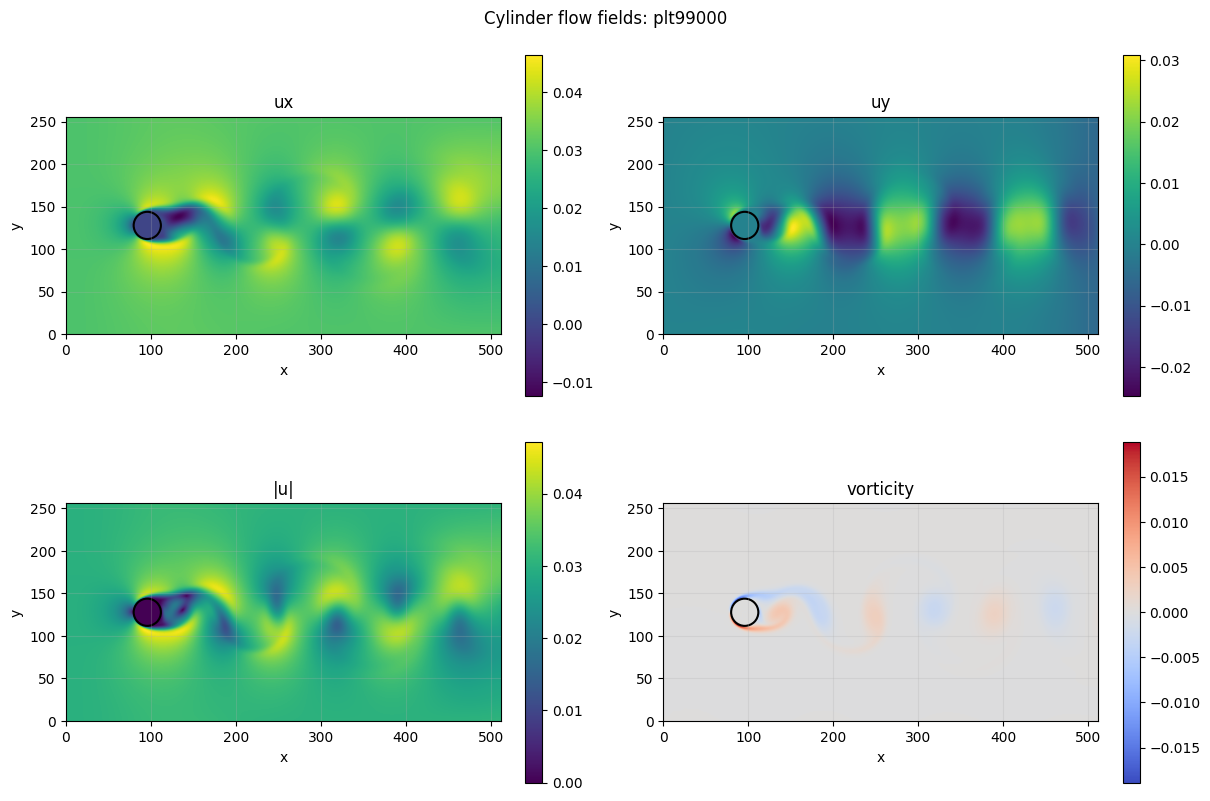

In [3]:
ds, extent, ux, uy, vor = load_fields2d(plotfile)
speed = np.sqrt(ux * ux + uy * uy)
vmax_vor = float(np.max(np.abs(vor)))
vor_norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax_vor, vmax=vmax_vor)

fig, ax = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
fields = [
    ('ux', ux, 'viridis', None),
    ('uy', uy, 'viridis', None),
    ('|u|', speed, 'viridis', None),
    ('vorticity', vor, 'coolwarm', vor_norm),
]

for axi, (name, arr, cmap, norm) in zip(ax.ravel(), fields):
    im = axi.imshow(arr.T, origin='lower', extent=extent, cmap=cmap, norm=norm, aspect='equal')
    add_cylinder(axi, x0, y0, radius)
    axi.set_title(name)
    axi.set_xlabel('x')
    axi.set_ylabel('y')
    fig.colorbar(im, ax=axi, shrink=0.9)

fig.suptitle(f'Cylinder flow fields: {plotfile.name}')
plt.show()


## Force History

The `Cd` y-range is chosen from the post-startup portion of the signal so the initial startup spike does not flatten the steady shedding regime.


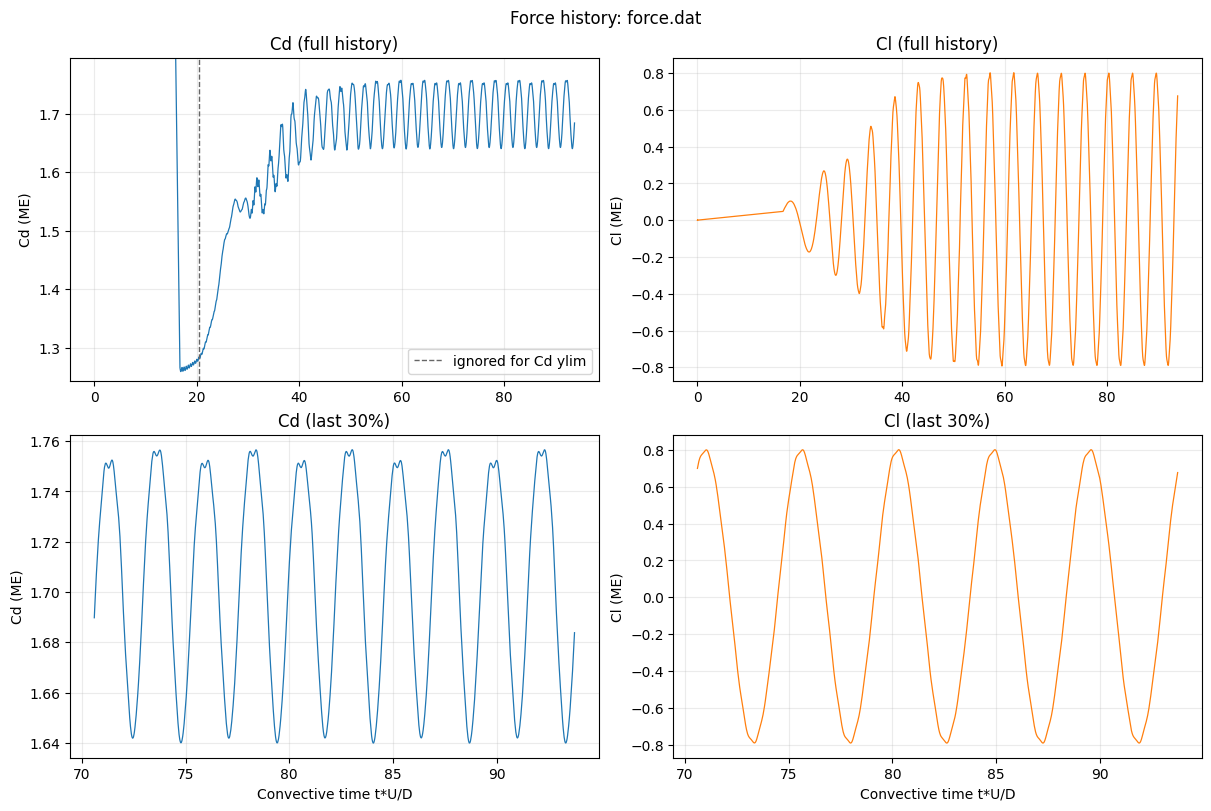

In [4]:
t, cd, cl = load_force(force_file)
tail_start = max(int((1.0 - TAIL_FRAC) * len(t)), 0)
(cd_ylim, cd_ignore_start) = trimmed_ylim(cd, ignore_frac=CD_YLIM_IGNORE_FRAC)

fig, ax = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

ax[0, 0].plot(t, cd, lw=0.9, color='tab:blue')
ax[0, 0].axvline(t[cd_ignore_start], color='0.4', ls='--', lw=1.0, label='ignored for Cd ylim')
ax[0, 0].set_title('Cd (full history)')
ax[0, 0].set_ylabel('Cd (ME)')
ax[0, 0].set_ylim(*cd_ylim)
ax[0, 0].legend()

ax[0, 1].plot(t, cl, lw=0.9, color='tab:orange')
ax[0, 1].set_title('Cl (full history)')
ax[0, 1].set_ylabel('Cl (ME)')

ax[1, 0].plot(t[tail_start:], cd[tail_start:], lw=0.9, color='tab:blue')
ax[1, 0].set_title(f'Cd (last {int(TAIL_FRAC * 100)}%)')
ax[1, 0].set_xlabel('Convective time t*U/D')
ax[1, 0].set_ylabel('Cd (ME)')

ax[1, 1].plot(t[tail_start:], cl[tail_start:], lw=0.9, color='tab:orange')
ax[1, 1].set_title(f'Cl (last {int(TAIL_FRAC * 100)}%)')
ax[1, 1].set_xlabel('Convective time t*U/D')
ax[1, 1].set_ylabel('Cl (ME)')

fig.suptitle(f'Force history: {force_file.name}')
plt.show()


## Lift Spectrum

A quick FFT view of the lift coefficient for checking the dominant shedding frequency.


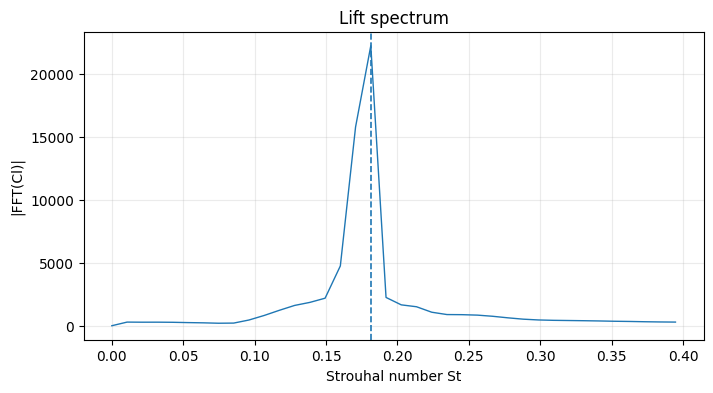

In [6]:
cl_centered = cl - np.mean(cl)
dt = (t[-1] - t[0]) / max(len(t) - 1, 1)
st = np.fft.rfftfreq(len(cl_centered), d=dt)
amp = np.abs(np.fft.rfft(cl_centered))
mask = st <= 0.4

# peak within plotted range
peak_idx = np.argmax(amp[mask])
peak_st = st[mask][peak_idx]


plt.figure(figsize=(8, 4))
plt.plot(st[mask], amp[mask], lw=1.0)
plt.axvline(peak_st, linestyle='--', linewidth=1.2)  # dashed line at peak
plt.xlabel('Strouhal number St')
plt.ylabel('|FFT(Cl)|')
plt.title('Lift spectrum')
plt.grid(alpha=0.25)
plt.show()
